In [ ]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import shap
import torch.nn as nn

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import save_checkpoint
from src.utils.reprodutibility import set_seed
from src.data.dataset import Sample

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")


c:\Users\emily\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [2]:
set_seed(42)

🔒 Seed fixada em: 42


Observação sobre adicionar features: Se você adicionar uma feature nova, a matriz de pesos da primeira camada mudará de tamanho (de N para N+1). É impossível ter exatamente os mesmos pesos, pois a arquitetura mudou. Porém, ao fixar a seed, os pesos das features antigas serão inicializados com os mesmos valores de antes, e a nova feature terá uma inicialização aleatória determinística. É a melhor comparação possível.

In [3]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["feature_windows"]["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")

# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados

📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 142


In [4]:
# Criar forecast columns (mesmos dados para início)
forecast_cols = {}
for station in stations:
    forecast_cols[station] = (
        f'precipitation_forecast_{station}',
        f'potential_evapotransp_forecast_{station}'
    )

In [5]:
# Criar dataset
print("\n📦 Criando dataset...")
train_ratio = data_config.get("train_ratio", 0.95)
train_indices = np.arange(0, int(len(combined_df) * train_ratio))

dataset = HydroDataset(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=train_indices,
    forecast_cols=forecast_cols,
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=api_k_list,
    static_keys=static_keys,
    window_stride=data_config.get("window_stride", 1),
)

print(f"✓ Dataset criado")
print(f"  Total de samples: {len(dataset)}")
print(f"  Encoder length: {dataset.encoder_length}")
print(f"  Decoder length: {dataset.decoder_length}")
print(f"  Decoder history: {dataset.decoder_history}")
print(f"  Decoder horizon: {dataset.decoder_horizon}")


📦 Criando dataset...
✓ Dataset criado
  Total de samples: 5933
  Encoder length: 380
  Decoder length: 153
  Decoder history: 135
  Decoder horizon: 18


In [6]:
# Célula 7: Split temporal
print("\n✂️ Criando split temporal...")
train_ds, val_ds = create_temporal_split_with_gap(
    dataset, 
    train_ratio=train_ratio,
    gap=data_config.get("gap", 128)
)

print(f"✓ Split criado")
print(f"  Treino: {len(train_ds)} samples")
print(f"  Validação: {len(val_ds)} samples")


✂️ Criando split temporal...
✓ Split criado
  Treino: 5636 samples
  Validação: 297 samples


In [7]:
# Célula 8: Criar DataLoaders
print("\n🔄 Criando DataLoaders...")
batch_size = train_config.get("batch_size", 64)

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True, 
    collate_fn=custom_collate_fn
)

val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)

print(f"✓ DataLoaders criados")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")



🔄 Criando DataLoaders...
✓ DataLoaders criados
  Batch size: 64
  Train batches: 88
  Val batches: 5


In [8]:
# Verificar dimensões
print("\n📐 Verificando dimensões...")
sample = dataset[0]

encoder_input_dim = sample.encoder_dyn.shape[-1]
decoder_dyn_features = sample.decoder_dyn.shape[-1]
temporal_features_dim = sample.temporal_dec.shape[-1]
n_stations = len(stations)
decoder_input_dim = decoder_dyn_features + temporal_features_dim + n_stations
static_dim = sample.static.shape[-1]

print(f"✓ Dimensões calculadas:")
print(f"  Encoder input dim: {encoder_input_dim}")
print(f"  Decoder input dim: {decoder_input_dim}")
print(f"  Static dim: {static_dim}")
print(f"  N stations: {n_stations}")



📐 Verificando dimensões...
✓ Dimensões calculadas:
  Encoder input dim: 21
  Decoder input dim: 55
  Static dim: 12
  N stations: 3


In [9]:
# Criar modelo
print("\n🧠 Criando modelo...")
device = get_device()

# Extrair parâmetros do modelo
arch_config = model_config["architecture"]
gate_config = model_config["gate"]
reg_config = model_config["regularization"]

model = Seq2SeqHydro(
    encoder_input_dim=encoder_input_dim,
    decoder_input_dim=decoder_input_dim,
    n_static=static_dim,
    hidden_dim=arch_config["hidden_dim"],
    num_layers=arch_config["num_layers"],
    dropout=arch_config["dropout"],
    n_stations=n_stations,
    attention=arch_config["attention"],
    residual=arch_config["residual"],
    non_negative=arch_config["non_negative"],
    input_noise_std=reg_config["input_noise_std"],
    y_prev_dropout_p=reg_config["y_prev_dropout_p"],
    gate_y_prev=gate_config["y_prev"],
    tf_step_decay=reg_config["tf_step_decay"],
    y_prev_mask_p=reg_config["y_prev_mask_p"],
    decoder_feat_dropout_p=reg_config["decoder_feat_dropout_p"],
    gate_from_inputs=gate_config["from_inputs"],
    clamp_gate_by_ceiling=gate_config["clamp_by_ceiling"],
    gate_ceiling_min=gate_config["ceiling_min"],
    detach_y_prev_in_gate=gate_config["detach_y_prev"],
    y_prev_mask_step_gamma=reg_config["y_prev_mask_step_gamma"],
    gate_min=gate_config["min"],
    gate_max=gate_config["max"],
)

print(f"✓ Modelo criado")
print(f"  Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {device}")


🧠 Criando modelo...
✓ Modelo criado
  Parâmetros totais: 3,131,910
  Device: cpu


In [27]:
# Célula 11: Treinar modelo
print("\n🚀 Iniciando treino...")
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    decoder_history=dataset.decoder_history,
    decoder_horizon=dataset.decoder_horizon,
    max_epochs=train_config["epochs"],
    initial_teacher_forcing=train_config["teacher_forcing"]["initial"],
    teacher_forcing_decay=train_config["teacher_forcing"]["decay"],
    final_teacher_forcing=train_config["teacher_forcing"]["final"],
    free_run_tail=train_config["teacher_forcing"]["free_run_tail"],
    lambda_smooth=train_config["loss_weights"]["smooth"],
    lambda_negative=train_config["loss_weights"]["negative"],
    lambda_continuity=train_config["loss_weights"]["continuity"],
    lambda_slope=train_config["loss_weights"]["slope"],
    horizon_weight_mode=train_config["horizon_weights"]["mode"],
    horizon_weight_gamma=train_config["horizon_weights"]["gamma"],
    early_free_run_patience=train_config["teacher_forcing"]["early_free_run_patience"],
    lambda_gate_bias=train_config["loss_weights"]["gate_bias"],
    gate_decay=train_config["gate_decay"],
    lambda_direction=train_config["loss_weights"]["direction"],
    direction_start=train_config["direction"]["start"],
    dir_weight_gamma=train_config["direction"]["weight_gamma"],
    patience=train_config["early_stopping"]["patience"],
    min_delta=train_config["early_stopping"]["min_delta"],
    learning_rate=train_config["learning_rate"],
    weight_decay=train_config["weight_decay"],
    clip_grad_norm=train_config["clip_grad_norm"],
    device=device,
)

print("✓ Treino concluído!")


🚀 Iniciando treino...
[Epoch 01] train=0.4986 val=0.0526 tf=0.600
[Epoch 02] train=0.0336 val=0.0579 tf=0.564
[Epoch 03] train=0.0306 val=0.0446 tf=0.530
[Epoch 04] train=0.0298 val=0.0472 tf=0.498
[Epoch 05] train=0.0268 val=0.0442 tf=0.468
[Epoch 06] train=0.0259 val=0.0459 tf=0.440
[Epoch 07] train=0.0247 val=0.0489 tf=0.414
[Epoch 08] train=0.0237 val=0.0492 tf=0.389
[Epoch 09] train=0.0214 val=0.0481 tf=0.366
[Epoch 10] train=0.0214 val=0.0465 tf=0.344
[Epoch 11] train=0.0208 val=0.0424 tf=0.323
[Epoch 12] train=0.0220 val=0.0462 tf=0.304
[Epoch 13] train=0.0199 val=0.0497 tf=0.286
[Epoch 14] train=0.0193 val=0.0491 tf=0.268
[Epoch 15] train=0.0186 val=0.0484 tf=0.252
[Epoch 16] train=0.0189 val=0.0452 tf=0.237
[Epoch 17] train=0.0176 val=0.0457 tf=0.223
[Epoch 18] train=0.0181 val=0.0532 tf=0.210
[Epoch 19] train=0.0167 val=0.0485 tf=0.197
[Epoch 20] train=0.0161 val=0.0474 tf=0.185
[Epoch 21] train=0.0159 val=0.0499 tf=0.174
Early stopping.
✓ Treino concluído!


In [ ]:
# 1. Coletar metadados vitais do Dataset
inference_meta = {
    "flow_scalers": dataset.flow_scalers,
    "climate_scalers": dataset.climate_scalers,
    "static_scalers": dataset.static_scalers,
    "stations": dataset.stations,
    "forecast_cols": dataset.forecast_cols,
    "flow_window_config": dataset.flow_window_config,
    "climate_window_config": dataset.climate_window_config,
    "temporal_features": dataset.temporal_features,
    "static_keys": dataset.static_keys,
    "decoder_history": dataset.decoder_history,
    "decoder_horizon": dataset.decoder_horizon,
}

# 2. Configuração da Arquitetura (Use as mesmas variáveis da criação do modelo)
# Se você usou um dicionário 'model_params', melhor ainda. Se não, monte agora:
model_config = {
    "encoder_input_dim": encoder_input_dim,
    "decoder_input_dim": decoder_input_dim,
    "n_static": static_dim,
    "hidden_dim":arch_config["hidden_dim"],
    "num_layers":arch_config["num_layers"],
    "dropout":arch_config["dropout"],
    "n_stations":n_stations,
    "attention":arch_config["attention"],
    "residual":arch_config["residual"],
    "non_negative":arch_config["non_negative"],
    "input_noise_std":reg_config["input_noise_std"],
    "y_prev_dropout_p":reg_config["y_prev_dropout_p"],
    "gate_y_prev":gate_config["y_prev"],
    "tf_step_decay":reg_config["tf_step_decay"],
    "y_prev_mask_p":reg_config["y_prev_mask_p"],
    "decoder_feat_dropout_p":reg_config["decoder_feat_dropout_p"],
    "gate_from_inputs":gate_config["from_inputs"],
    "clamp_gate_by_ceiling":gate_config["clamp_by_ceiling"],
    "gate_ceiling_min":gate_config["ceiling_min"],
    "detach_y_prev_in_gate":gate_config["detach_y_prev"],
    "y_prev_mask_step_gamma":reg_config["y_prev_mask_step_gamma"],
    "gate_min":gate_config["min"],
    "gate_max":gate_config["max"],
}

# 3. Salvar
save_checkpoint(
    model=trained_model,
    inference_meta=inference_meta,
    model_config=model_config,
    path="C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/models/modelo_hidrologico_v2.pth")

✅ Checkpoint salvo com sucesso em: C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/modelsmodelo_hidrologico_v1.pth


Nota Importante: Como o dataset agora é dinâmico, quando você for usar esse modelo salvo para fazer previsões em novos dados, certifique-se de que o DataFrame de entrada tenha as mesmas colunas (mesmas janelas de média móvel, etc.) que foram usadas no treino. Se o DataFrame novo tiver colunas a mais ou a menos, o modelo poderá reclamar de erro de dimensão.

In [30]:
# Célula 12: Fazer previsões
print("\n🔮 Fazendo previsões...")
preds, obs, baseline_last, g_seq, forecast_dates, _ = predict_autoregressive(
    model=trained_model,
    loader=val_loader,
    decoder_history=dataset.decoder_history,
    decoder_horizon=dataset.decoder_horizon,
    scalers=dataset.flow_scalers,
    stations=stations,
    clamp_non_negative=True,
    device=device,
)

print(f"✓ Previsões realizadas")
print(f"  Shape preds: {preds.shape}")
print(f"  Shape obs: {obs.shape}")
print(f"  N forecast dates: {len(forecast_dates)}")


🔮 Fazendo previsões...
✓ Previsões realizadas
  Shape preds: (297, 18, 3)
  Shape obs: (297, 18, 3)
  N forecast dates: 297


{10100000: {'overall': {'rmse': 2376.115526231427, 'mae': 1540.6619256073466, 'mape': 5.801782468034914, 'r2': 0.9689317996294374, 'nse': 0.9689317996294374, 'kge': 0.948334815866045, 'skill_rmse': 0.36218726403446233}, 'macro': {'rmse': 2153.9656730865095, 'mae': 1540.6618400150223, 'mape': 5.801782145713684, 'r2': 0.969731807934268, 'nse': 0.969731807934268}, 'per_horizon': {'rmse': [252.3503457844693, 502.8665581864946, 766.2526859430961, 1035.7645168483032, 1309.2086421128736, 1577.2451308019597, 1835.1296758157894, 2075.4437847764816, 2295.11217149976, 2492.689707649916, 2666.002323543022, 2815.5995123878242, 2944.4314716123226, 3056.836081752671, 3156.623028596239, 3247.4551242710154, 3331.960283571214, 3410.4132243693934], 'mae': [167.648641361532, 339.0074310816498, 517.8735335122054, 704.0360571864478, 893.6591763994107, 1074.3675557659933, 1256.9131221064815, 1429.728265730219, 1595.8495107323233, 1754.24108270202, 1897.4740438236531, 2024.7630865951178, 2137.5895017887206, 2

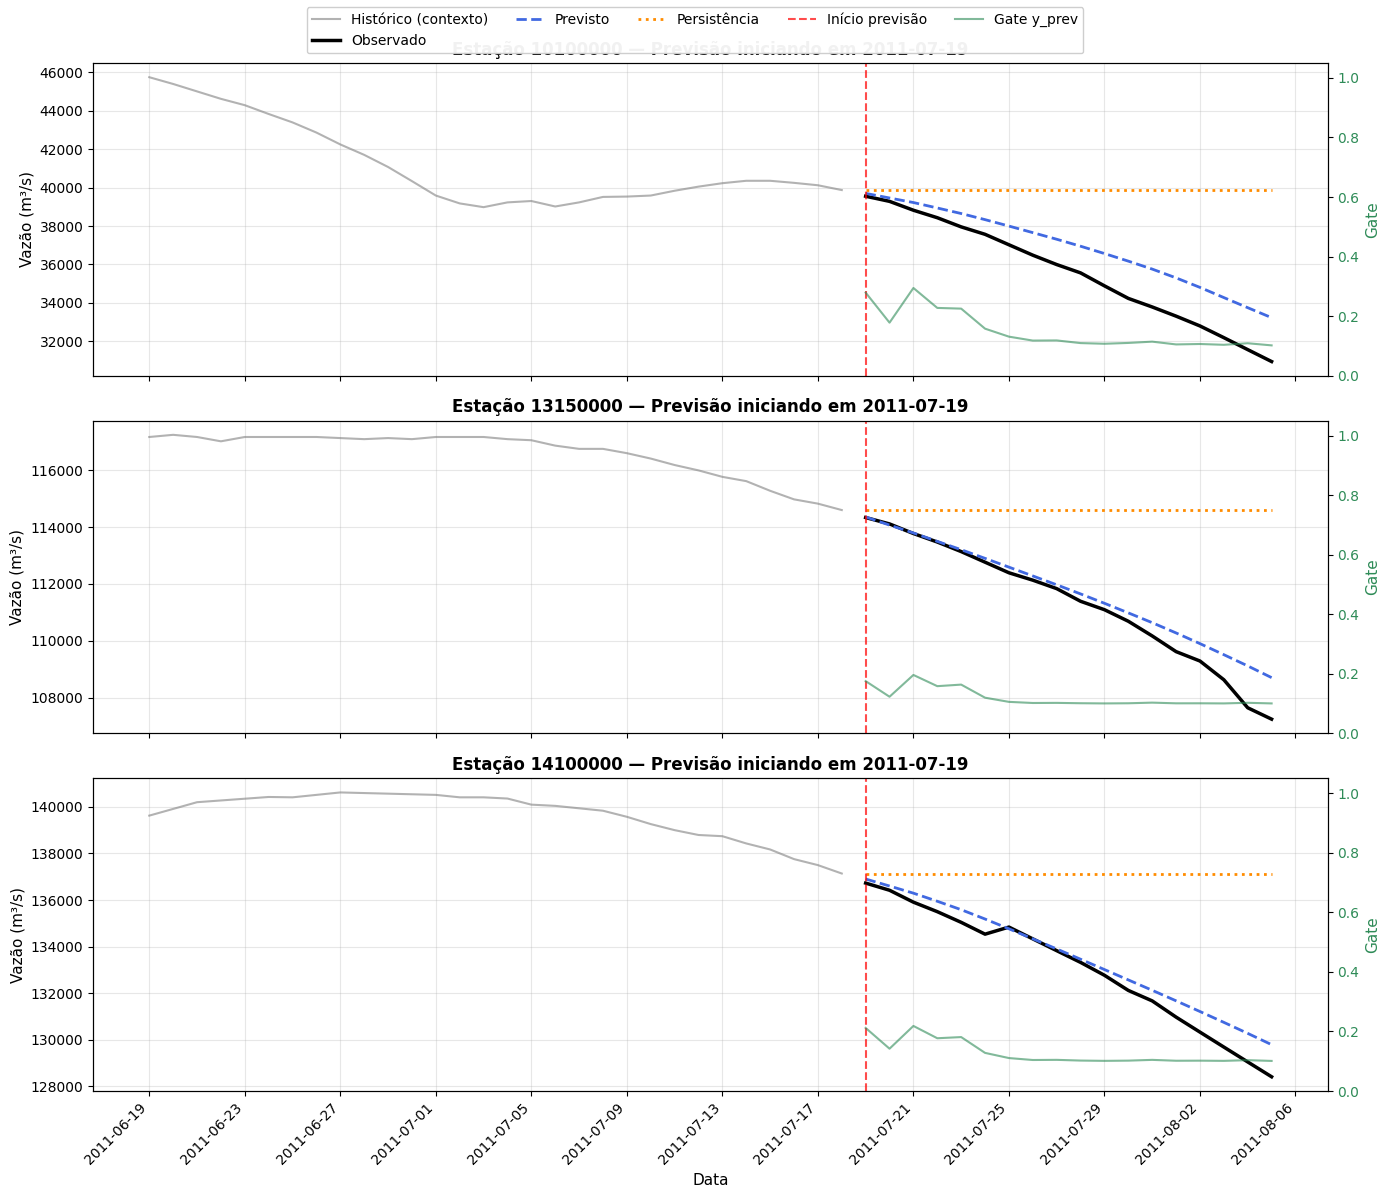

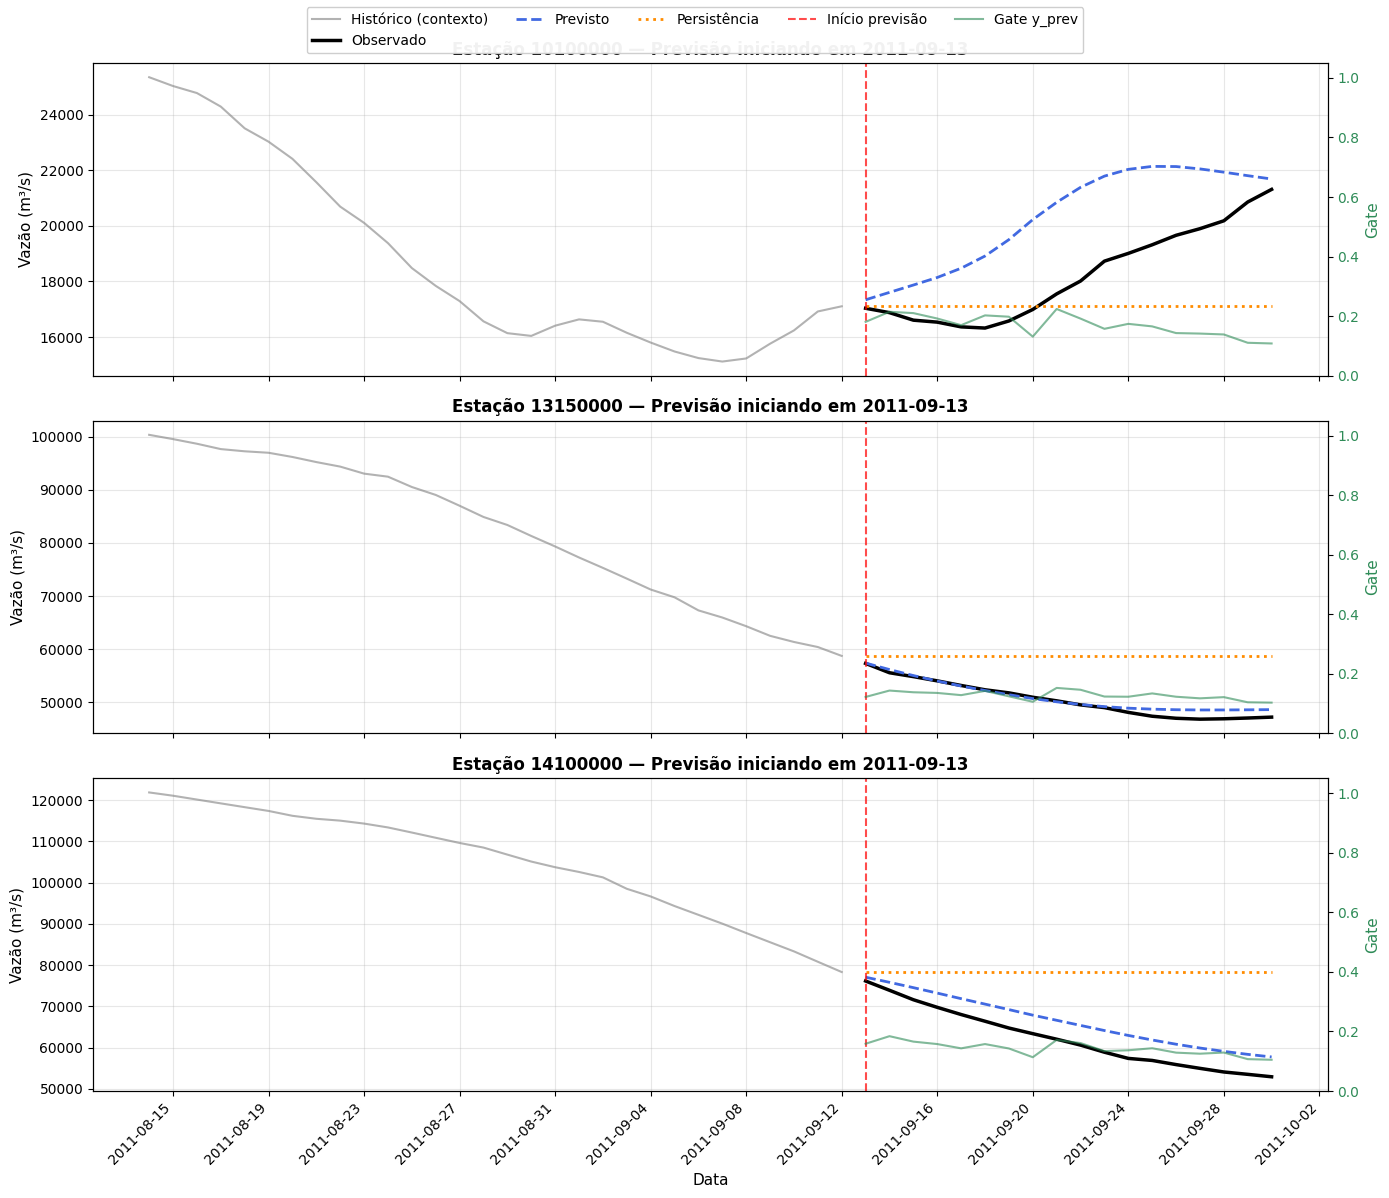

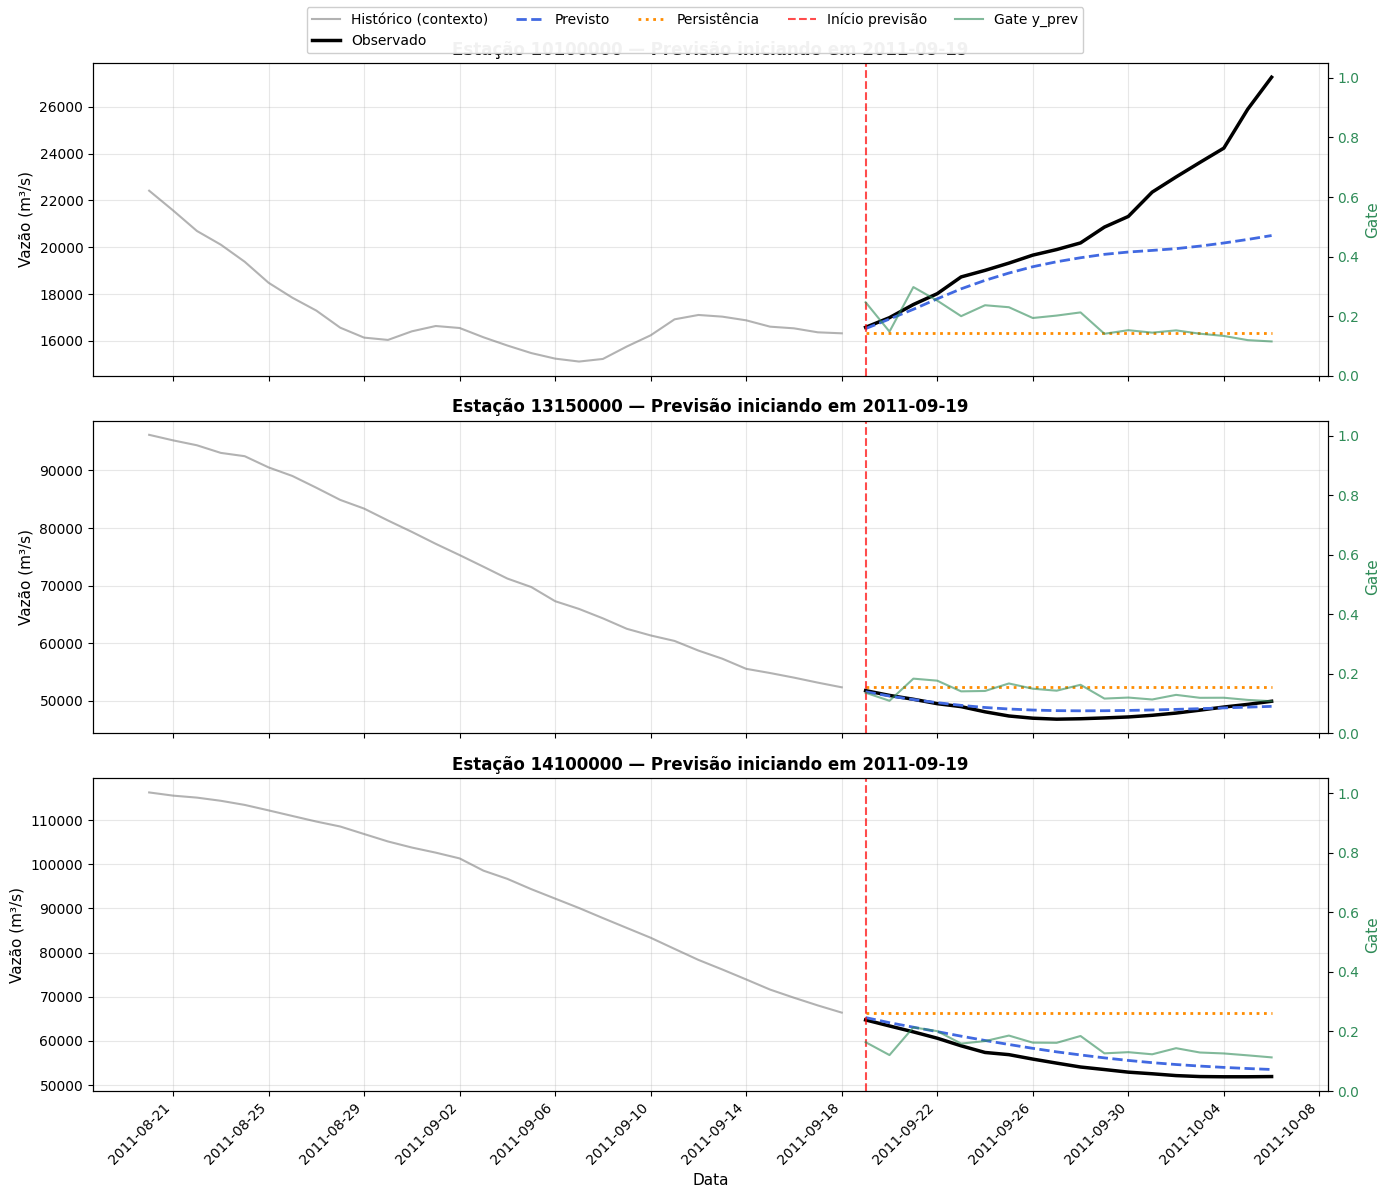

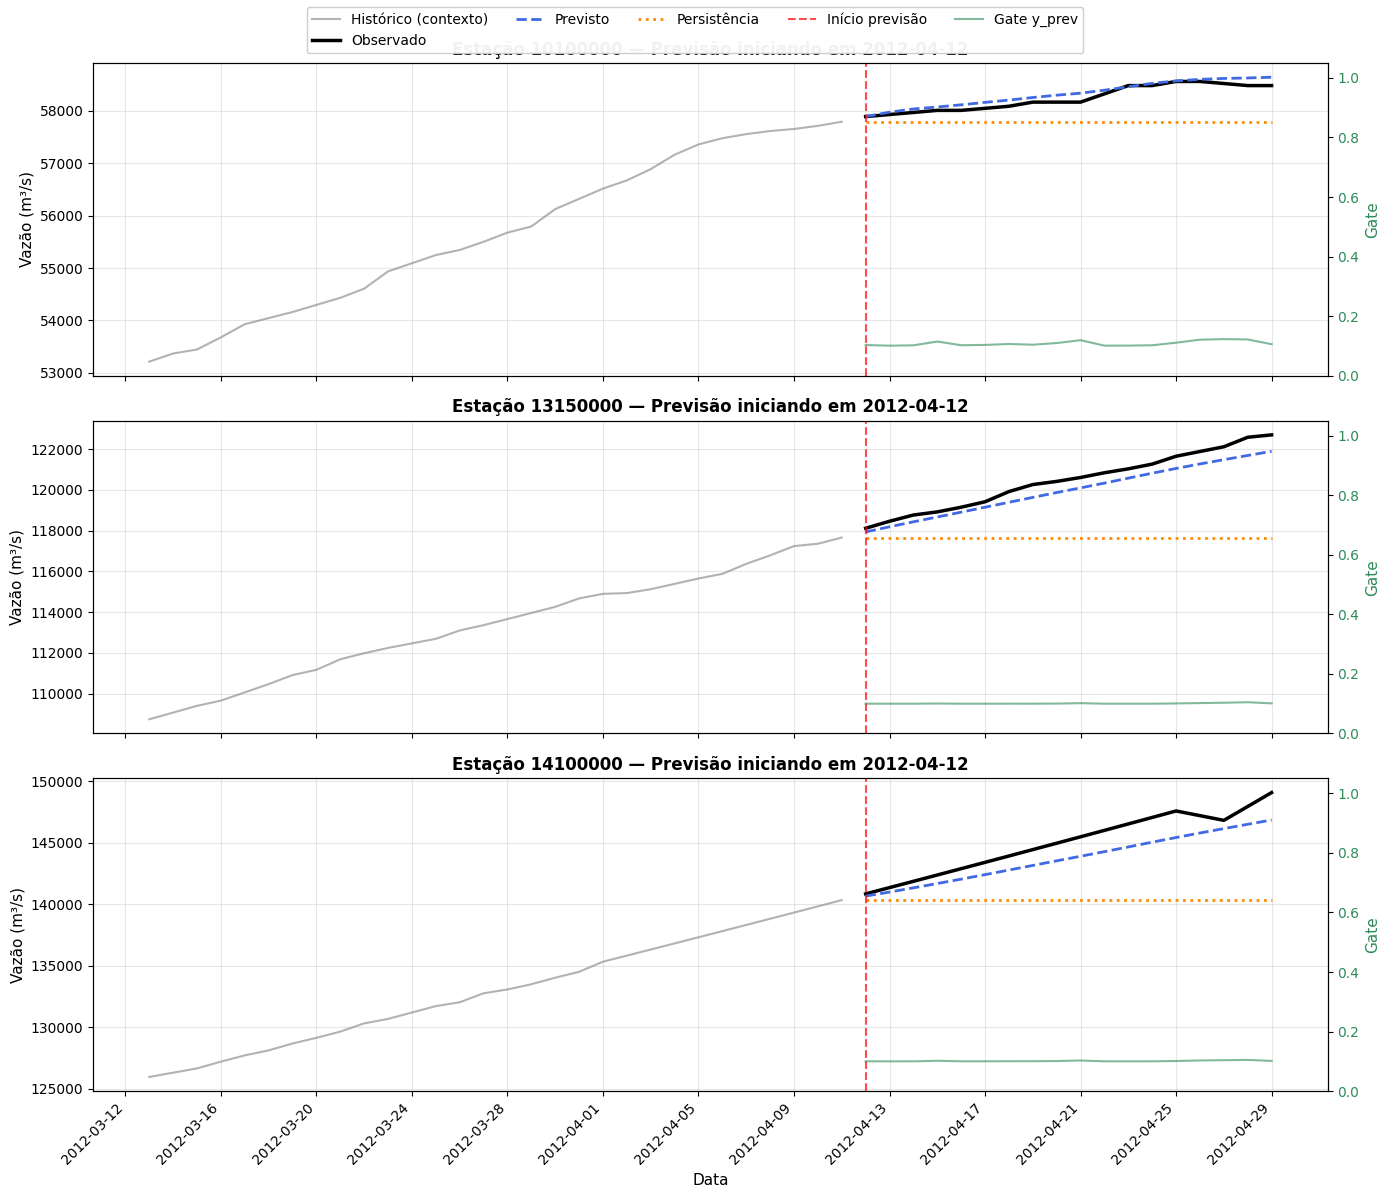

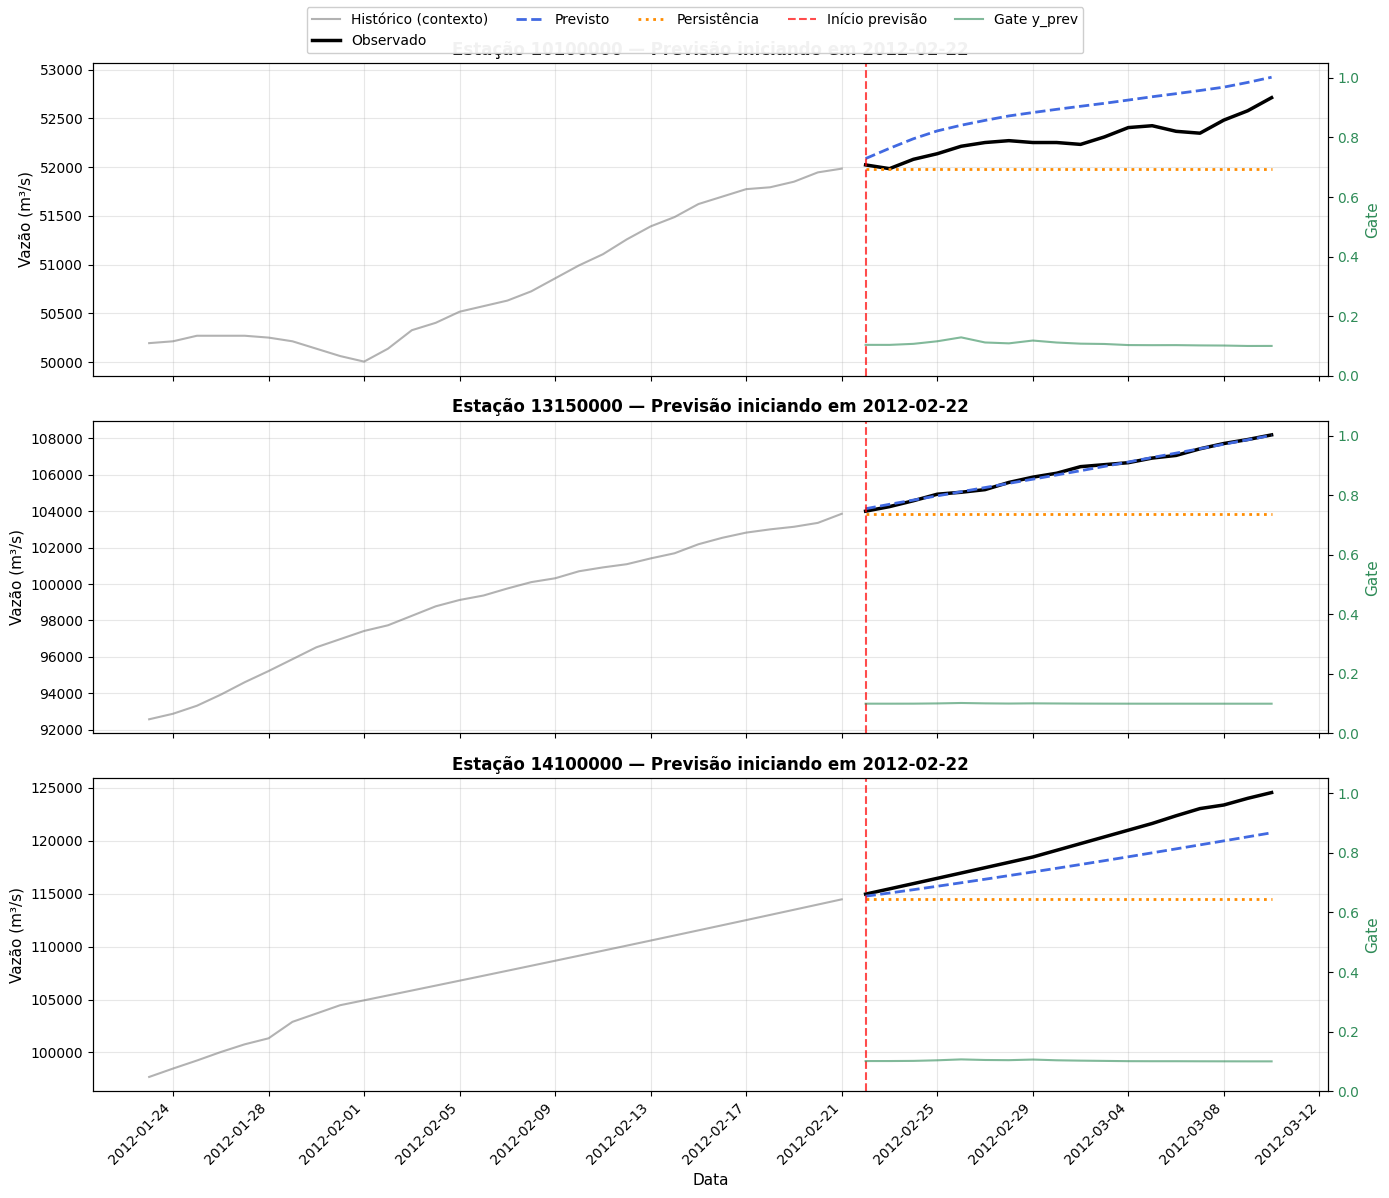

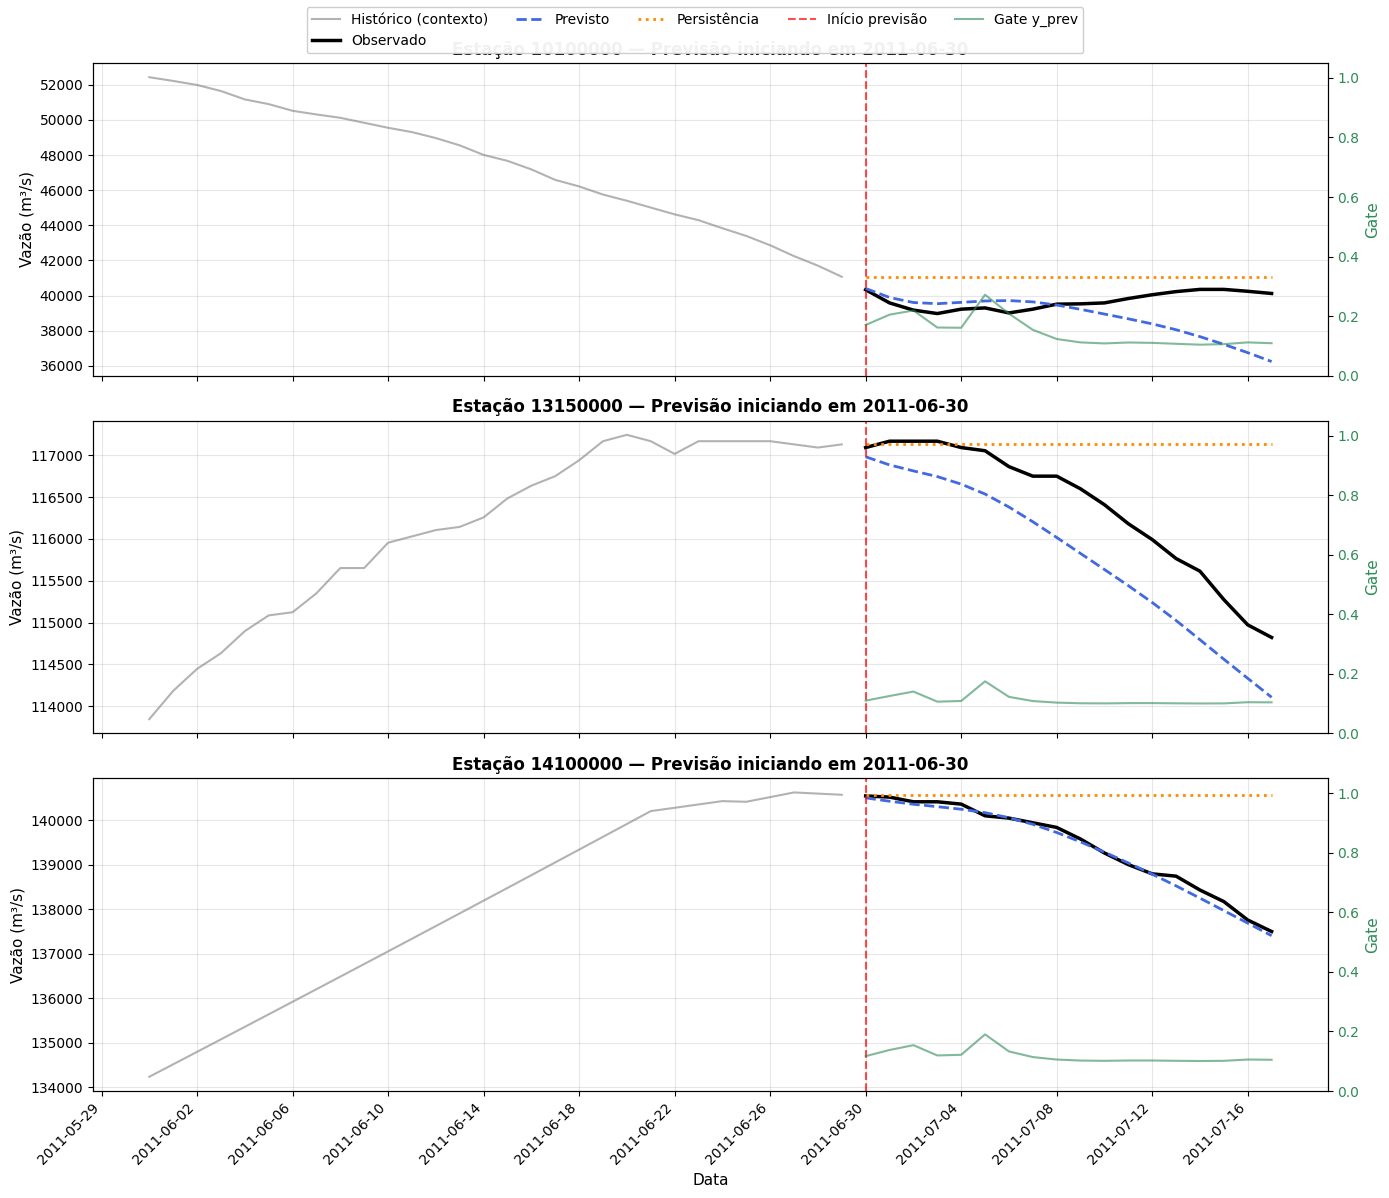

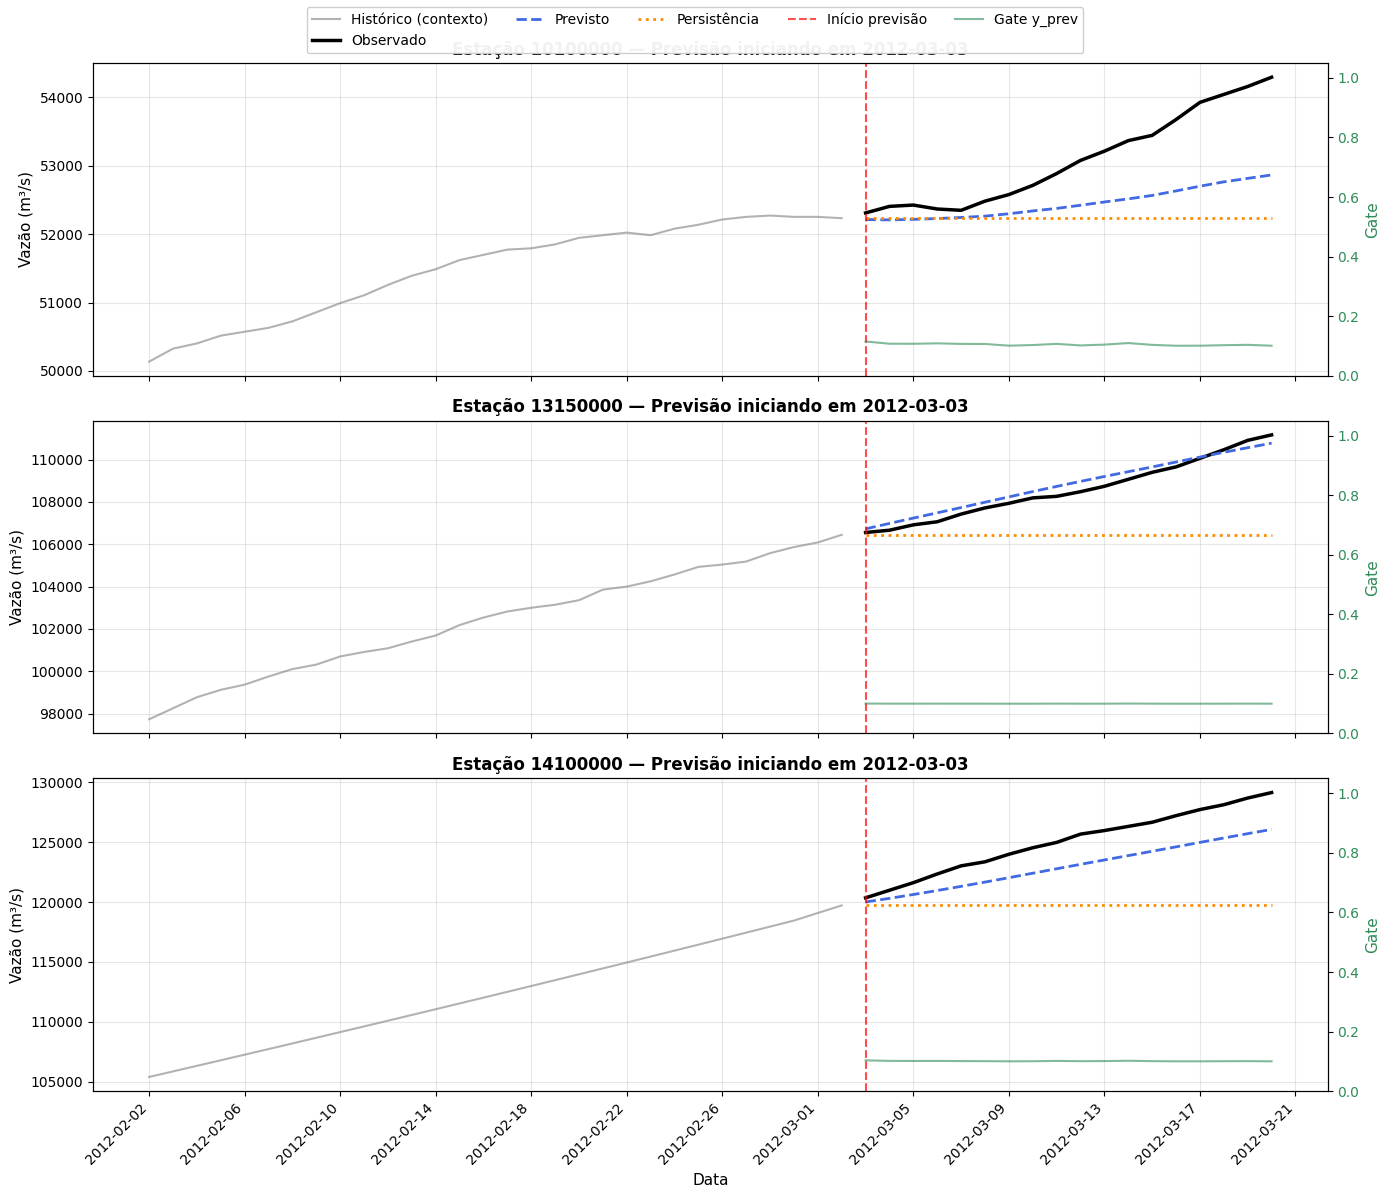

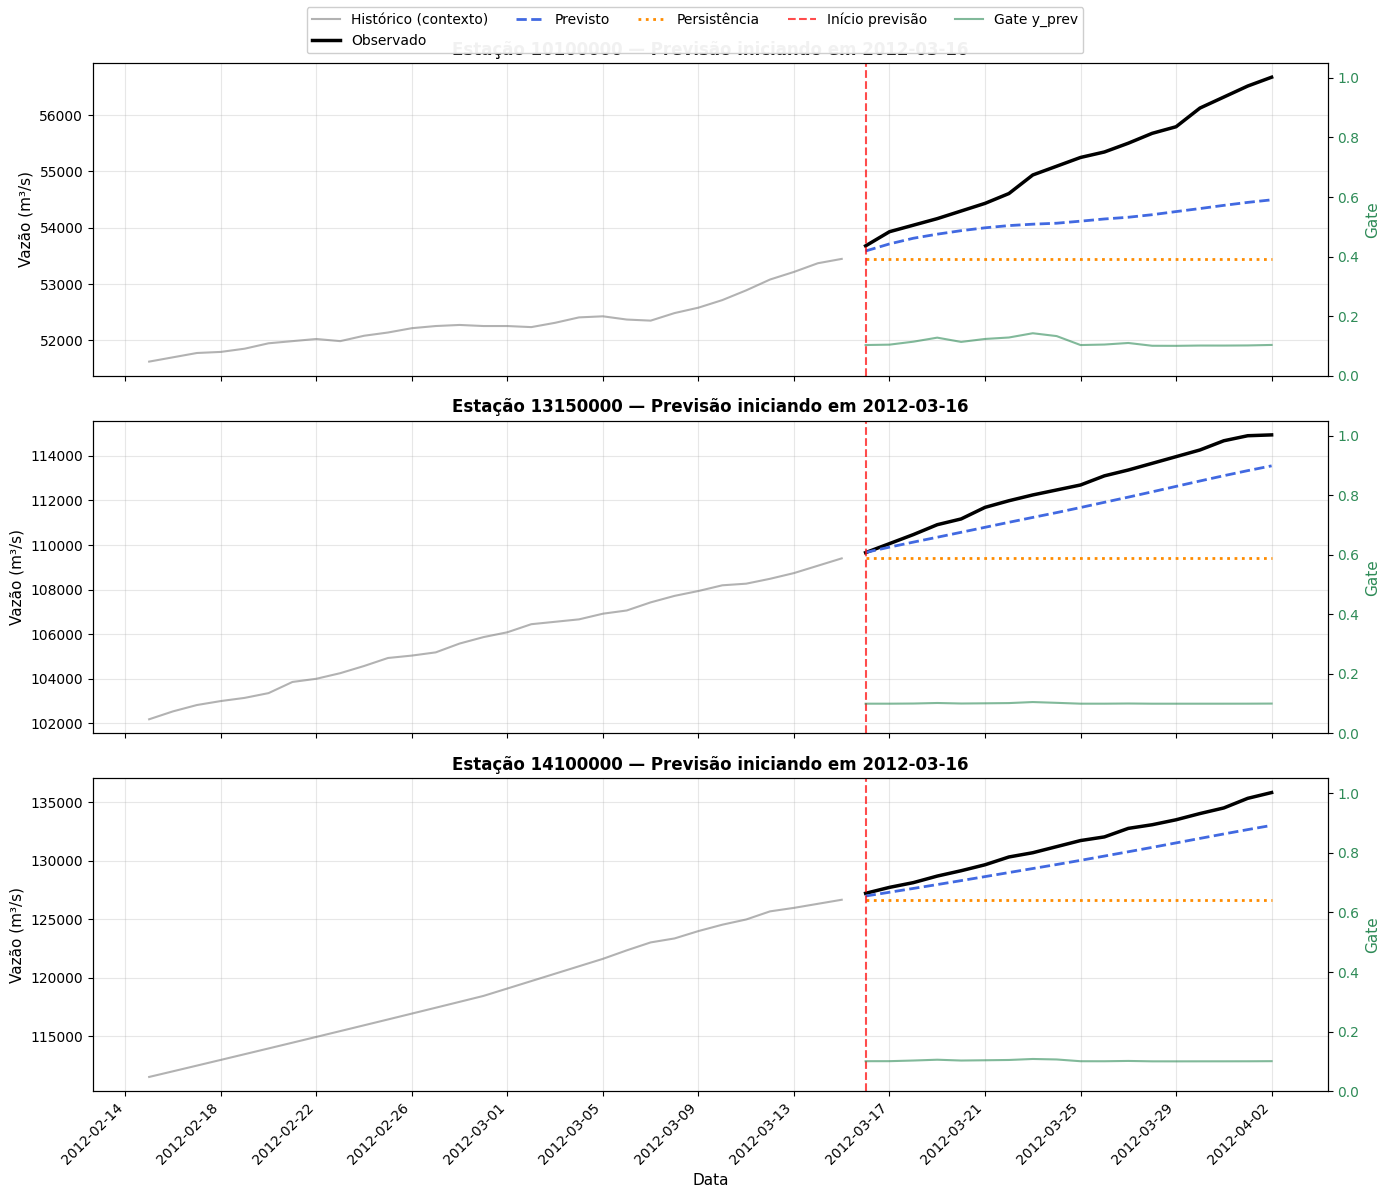

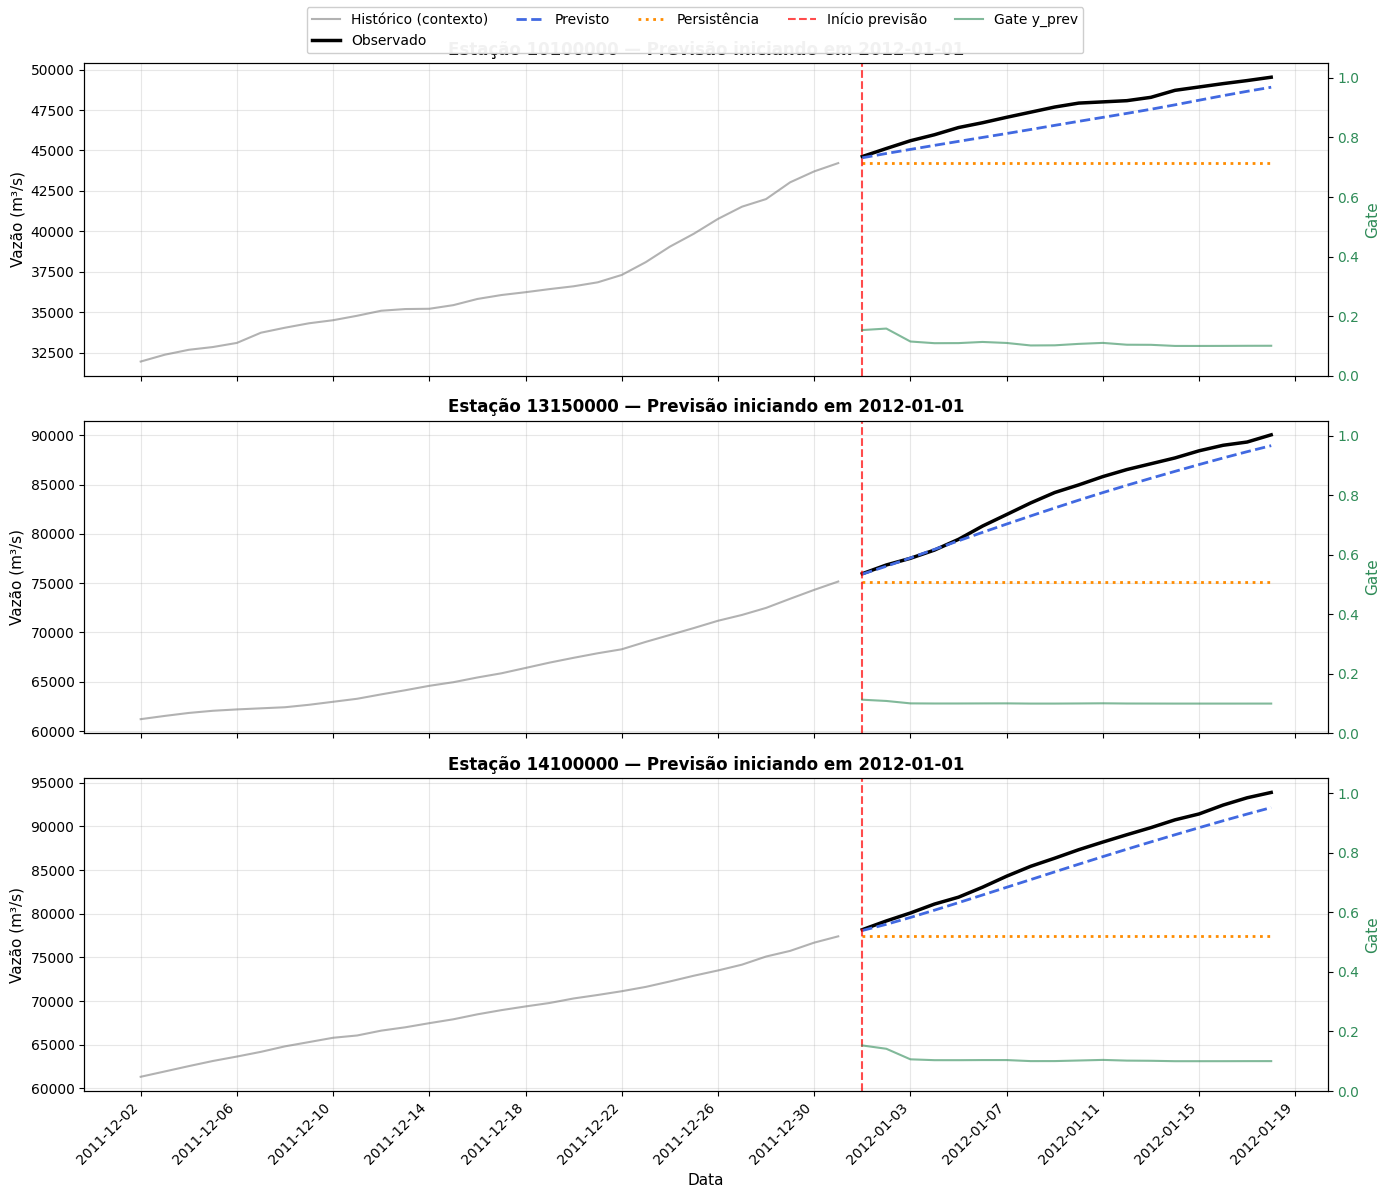

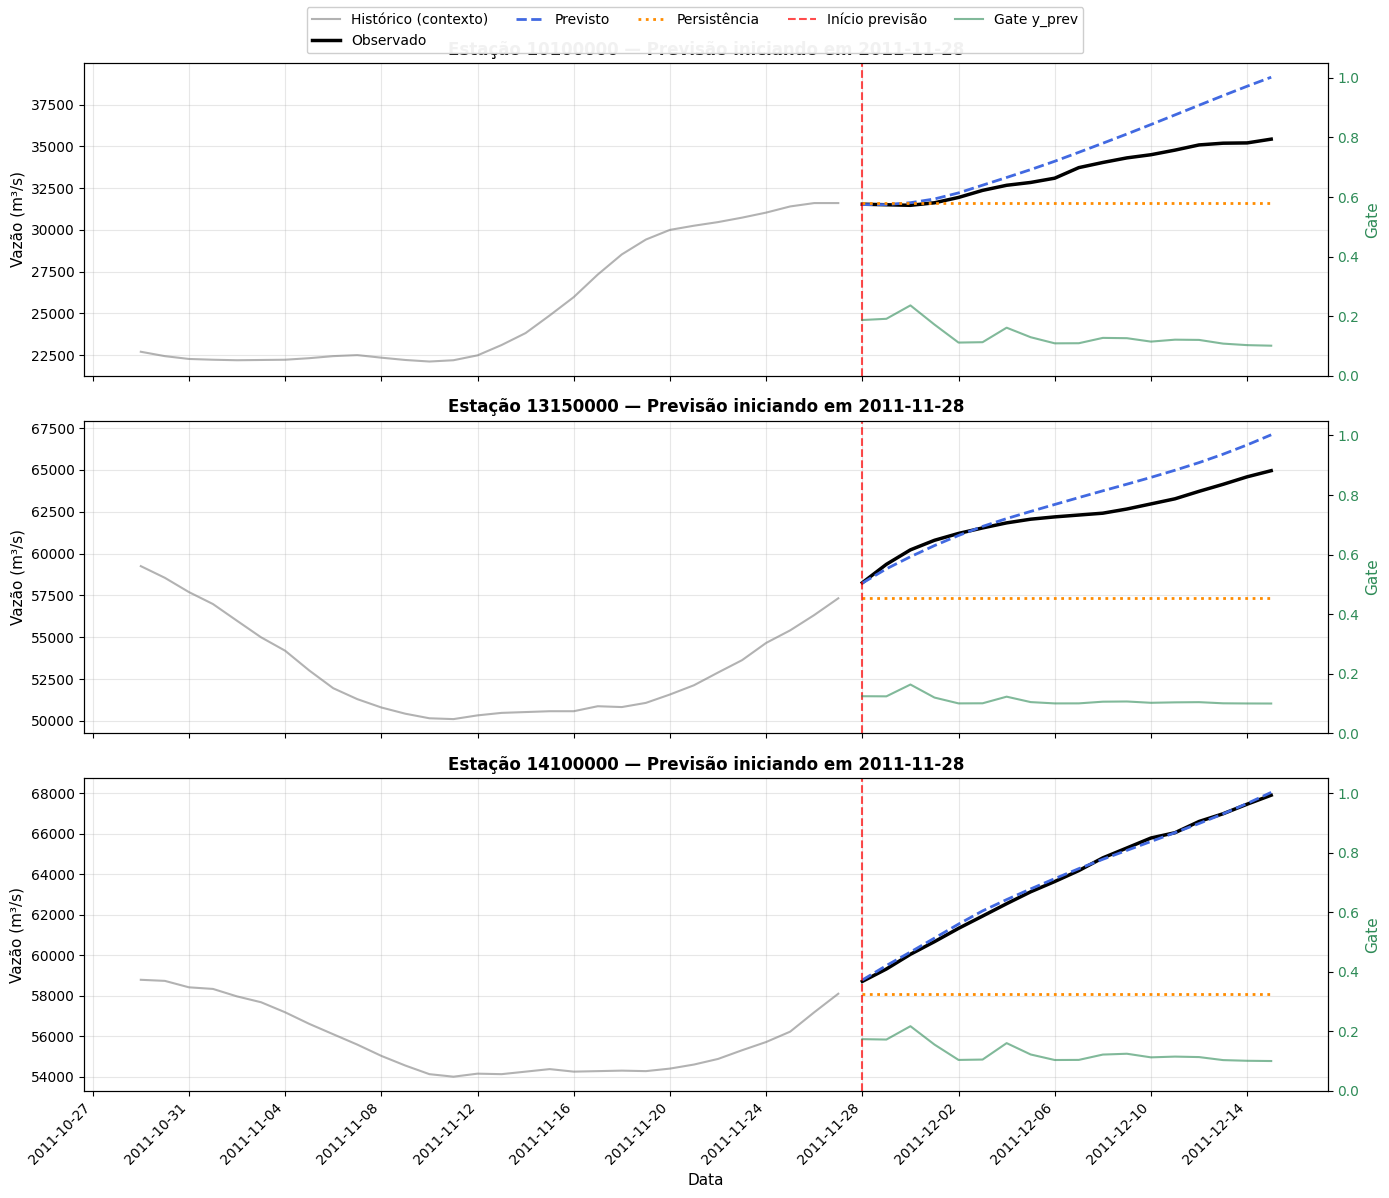

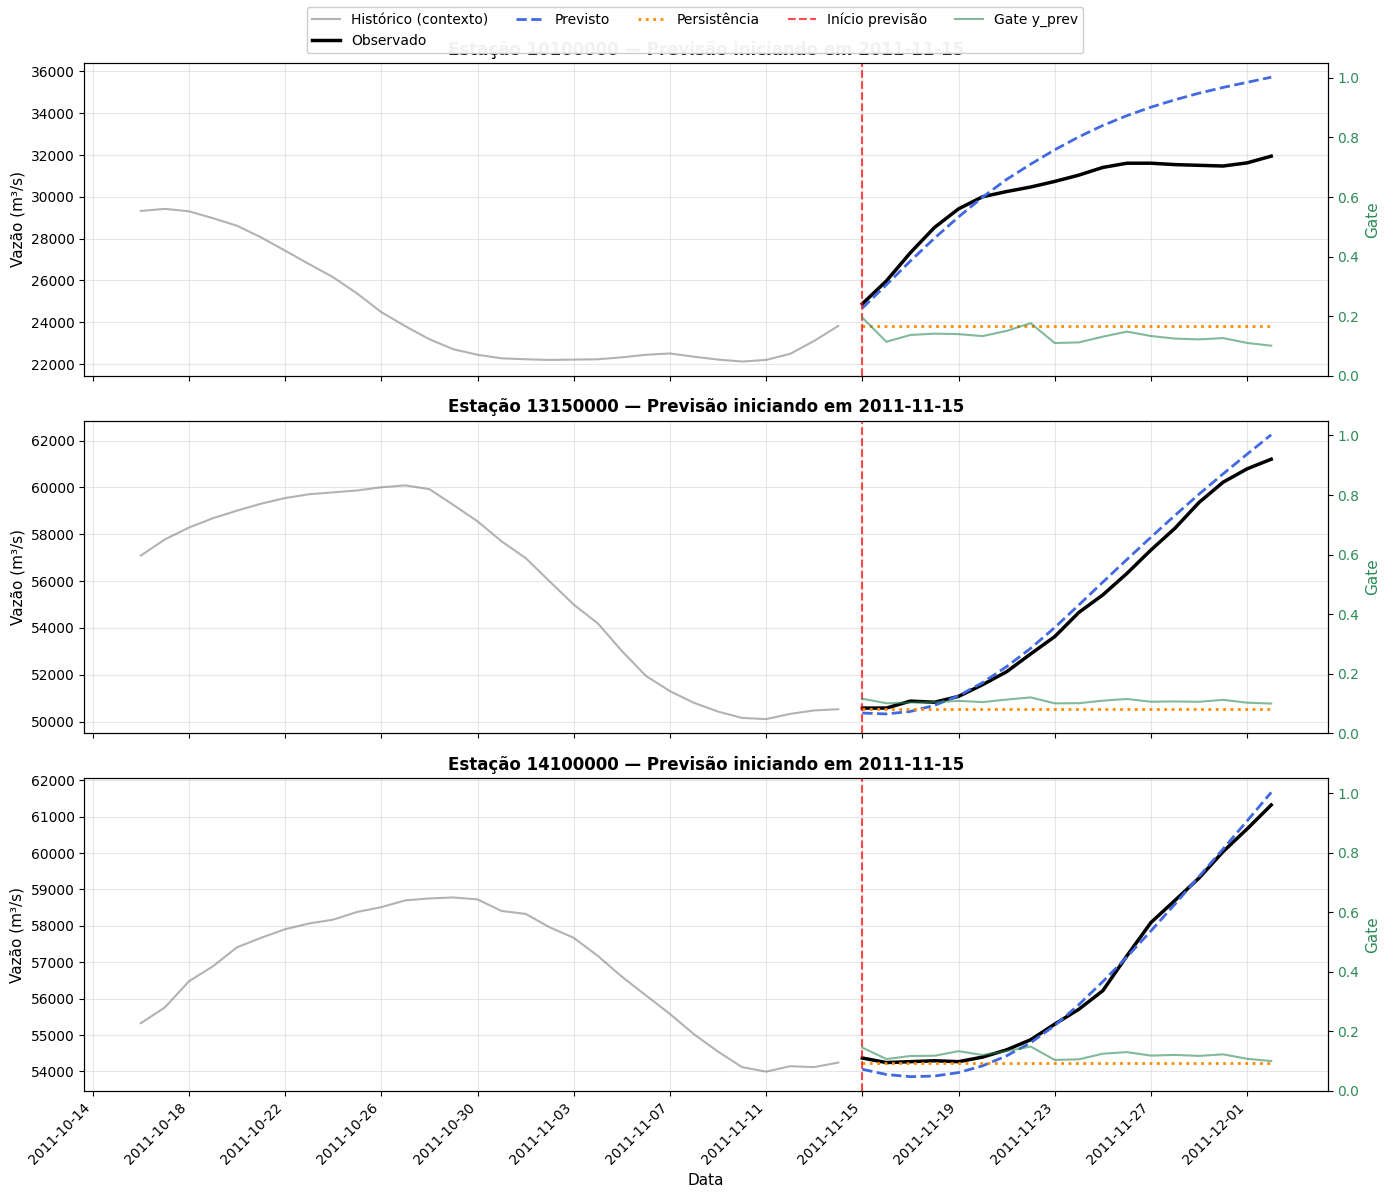

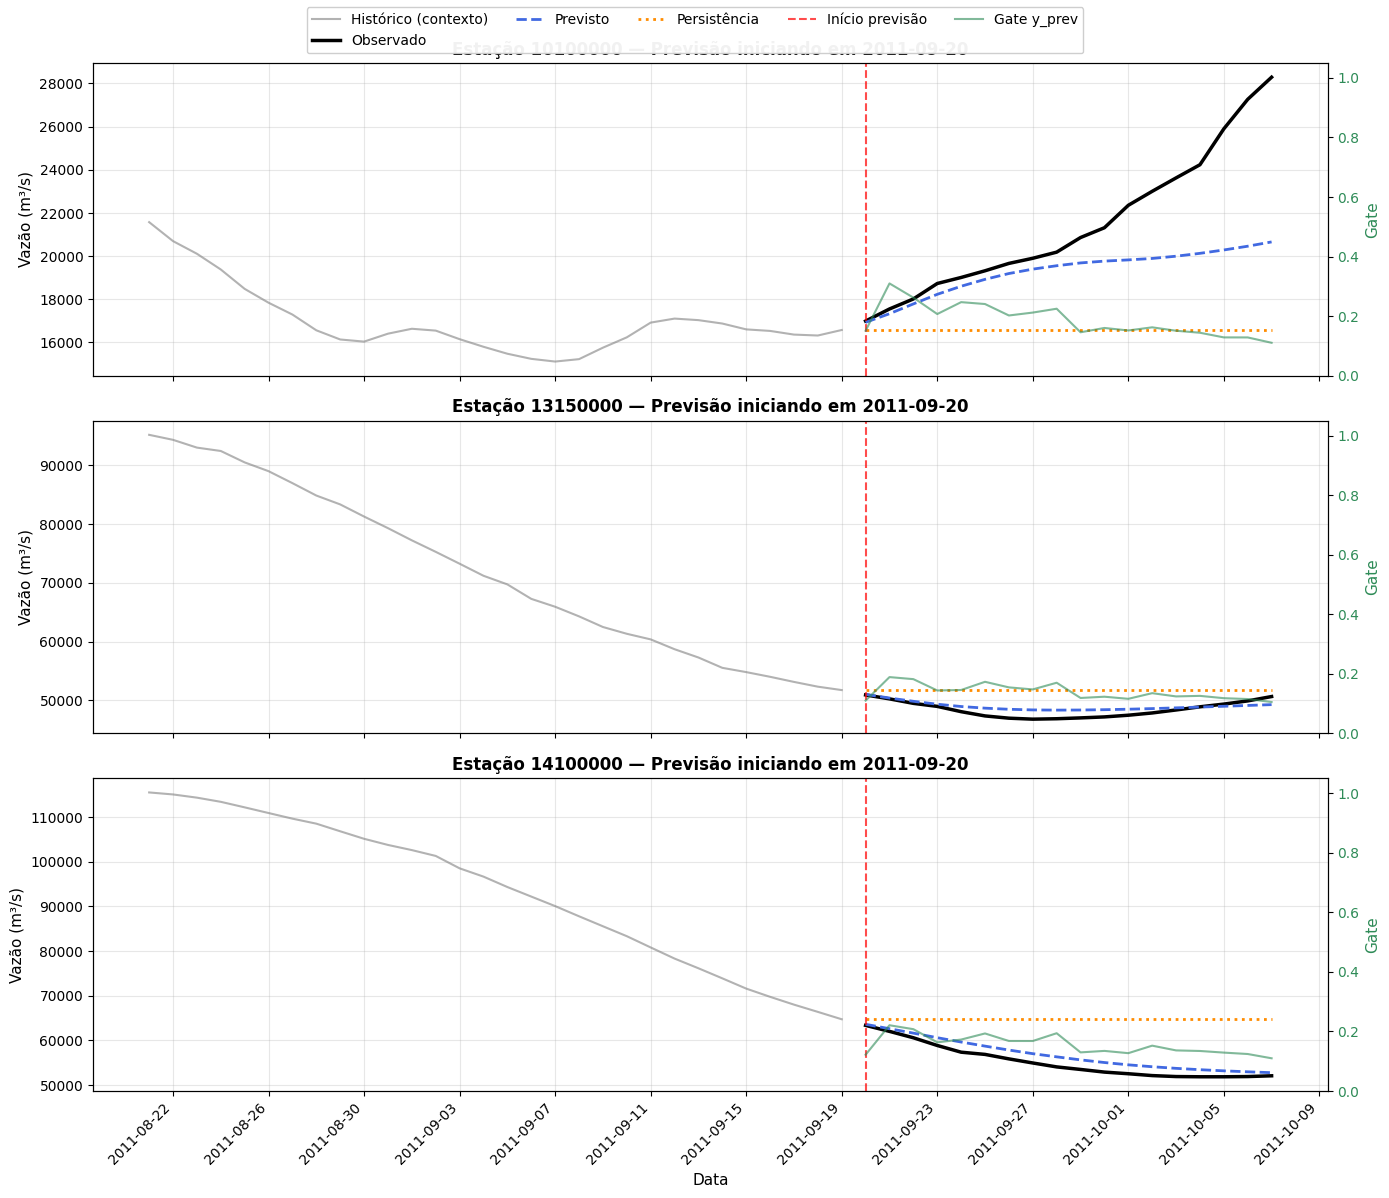

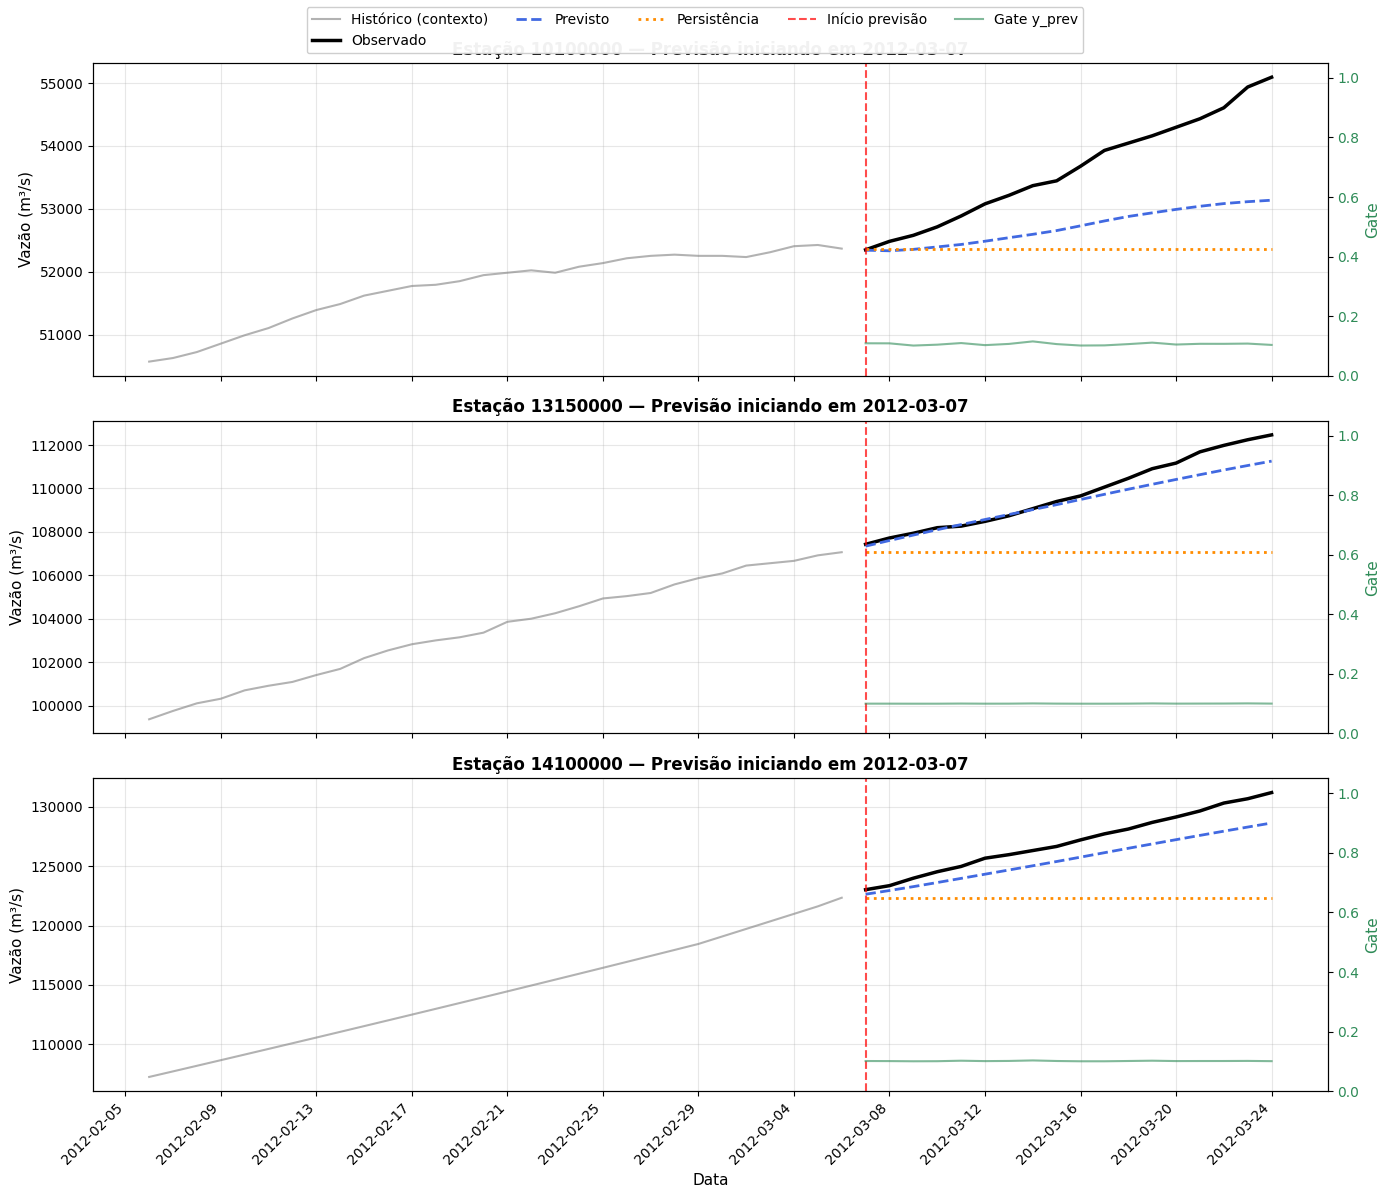

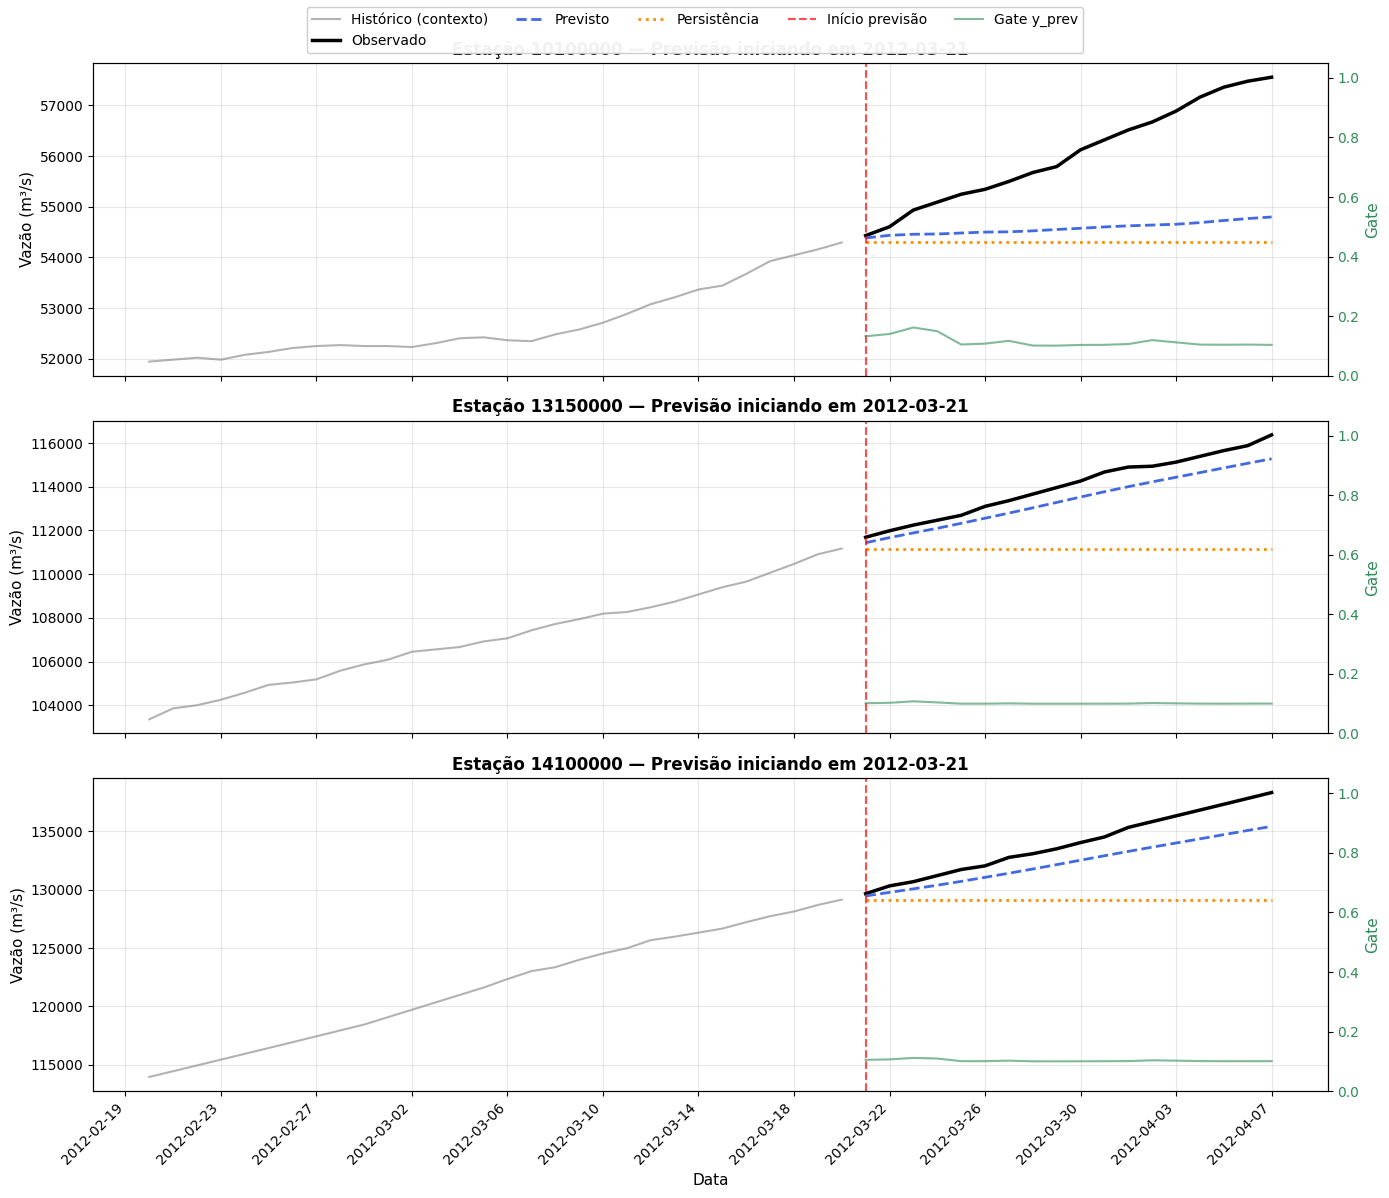

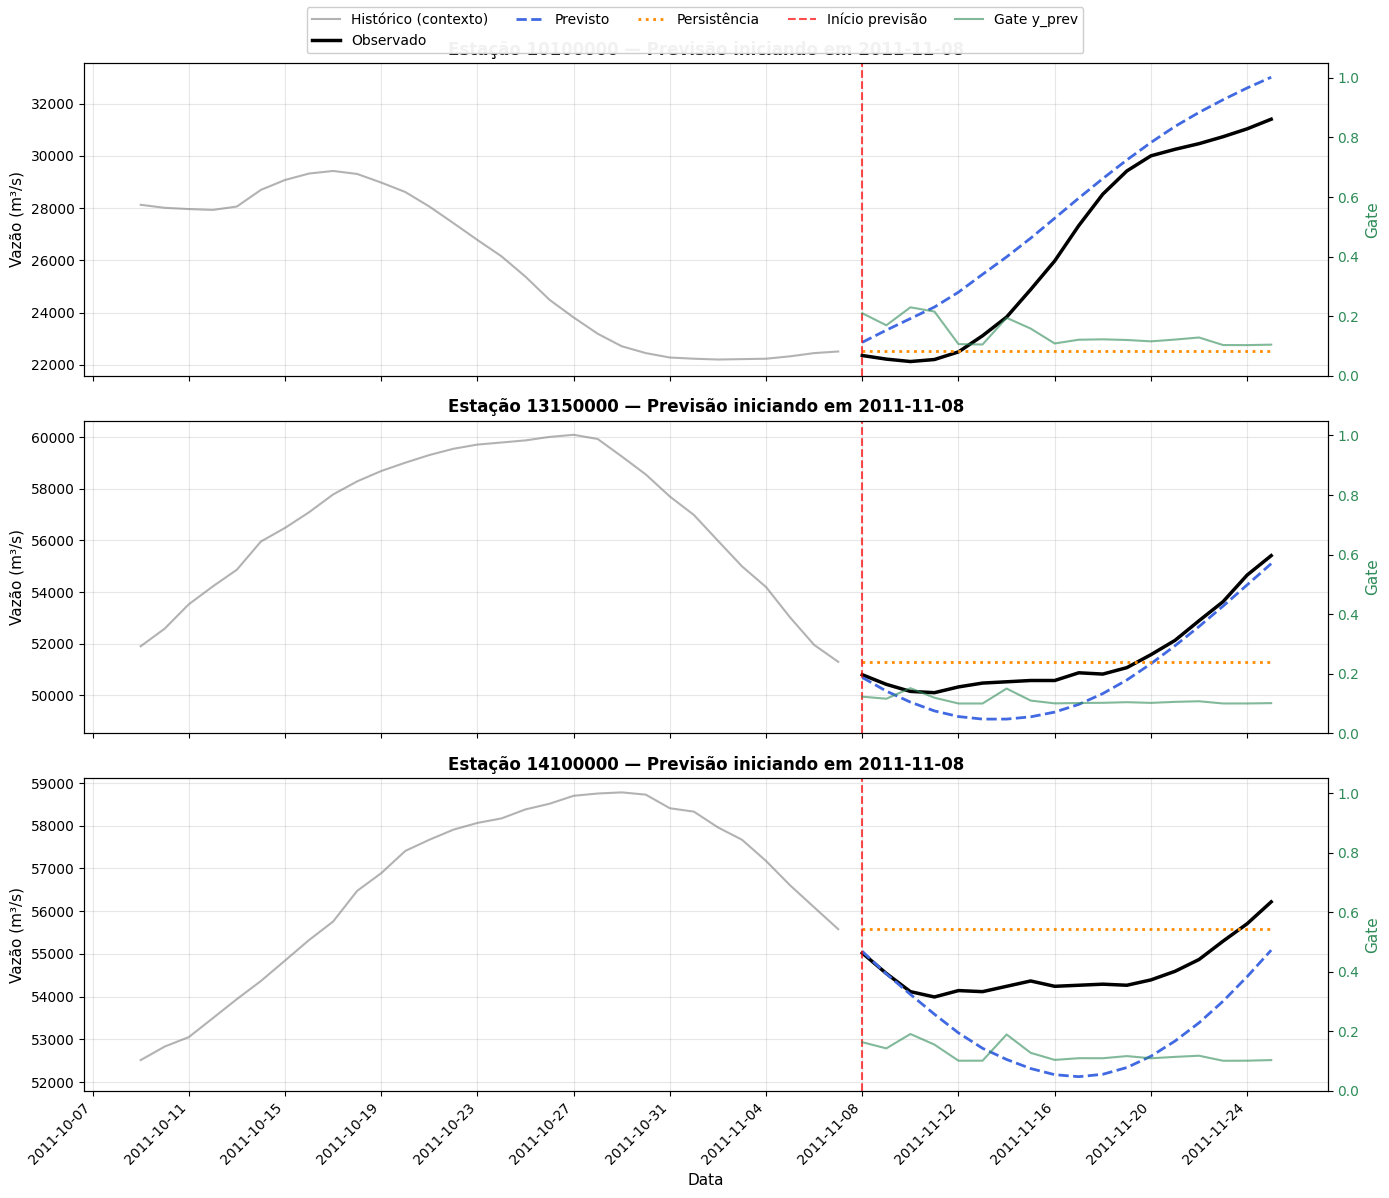

In [31]:
# Métricas gerais
metrics = compute_flow_metrics(
    preds,
    obs, 
    stations, 
    baseline_last=baseline_last)

print(metrics)
    
# 4. Visualizações
plot_predictions_with_context(
        preds=preds,
        obs=obs,
        stations=stations,
        df=combined_df,
        forecast_dates=forecast_dates,
        n_samples=15,
        context_days=30,
        baseline_last=baseline_last,
        g_seq=g_seq,
    )

### Shap analysis

In [ ]:
# ── CÉLULA SHAP 2: Wrapper do modelo para o SHAP ────────────────────────────
#
# Problema: o SHAP precisa de uma função  tensor → tensor
# mas o forward() do Seq2SeqHydro recebe um objeto Sample.
#
# Solução: wrapper que recebe só encoder_dyn e reconstrói
# o Sample internamente, fixando os demais inputs com a
# média do background (representativa, não arbitrária).

class EncoderSHAPWrapper(nn.Module):
    def __init__(self, model, fixed_sample, decoder_history, decoder_horizon):
        super().__init__()
        self.model = model
        self.decoder_history = decoder_history
        self.decoder_horizon = decoder_horizon

        # Fixa os demais tensors com a média do background
        # register_buffer garante que ficam no device correto automaticamente
        self.register_buffer('dec_dyn',       fixed_sample.decoder_dyn.mean(0, keepdim=True))
        self.register_buffer('static',        fixed_sample.static.mean(0, keepdim=True))
        self.register_buffer('temporal_enc',  fixed_sample.temporal_enc.mean(0, keepdim=True))
        self.register_buffer('temporal_dec',  fixed_sample.temporal_dec.mean(0, keepdim=True))
        self.register_buffer('target',        fixed_sample.target.mean(0, keepdim=True))
        self.register_buffer('mask_enc',      fixed_sample.mask_enc.mean(0, keepdim=True))
        self.register_buffer('mask_dec',      fixed_sample.mask_dec.mean(0, keepdim=True))
        self.register_buffer('baseline_last', fixed_sample.baseline_last.mean(0, keepdim=True))

    def forward(self, encoder_dyn):
        """encoder_dyn: (batch, enc_len, enc_features) → (batch,) média das previsões"""
        B = encoder_dyn.size(0)
        sample = Sample(
            encoder_dyn  = encoder_dyn,
            decoder_dyn  = self.dec_dyn.expand(B, -1, -1),
            static       = self.static.expand(B, -1),
            temporal_enc = self.temporal_enc.expand(B, -1, -1),
            temporal_dec = self.temporal_dec.expand(B, -1, -1),
            target       = self.target.expand(B, -1, -1),
            mask_enc     = self.mask_enc.expand(B, -1, -1),
            mask_dec     = self.mask_dec.expand(B, -1, -1),
            baseline_last= self.baseline_last.expand(B, -1),
            forecast_date= None,
            date_index   = None,
        )
        with torch.no_grad():
            preds, _, _ = self.model(sample, 0.0, self.decoder_history, self.decoder_horizon)
        # preds: (B, horizon, n_stations) → escalar médio por amostra
        return preds.mean(dim=(1, 2), keepdim=False).unsqueeze(-1)  # shape: (B, 1)

print('✓ Wrapper definido')

In [56]:
# ── CÉLULA SHAP 3: Coletar dados do val_loader ──────────────────────────────

def collect_batches(loader, device='cpu'):
    """Concatena todos os batches do loader em um Sample único."""
    keys = ['encoder_dyn', 'decoder_dyn', 'static',
            'temporal_enc', 'temporal_dec', 'target',
            'mask_enc', 'mask_dec', 'baseline_last']
    parts = {k: [] for k in keys}

    for batch in loader:
        for k in keys:
            parts[k].append(getattr(batch, k))

    return Sample(
        **{k: torch.cat(v, dim=0).to(device) for k, v in parts.items()},
        forecast_date=None,
        date_index=None,
    )

# SHAP funciona melhor em CPU — mantém mesmo que o treino tenha sido em GPU
shap_device = 'cpu'
trained_model.eval().to(shap_device)

print('Coletando dados de validação...')
val_sample = collect_batches(val_loader, device=shap_device)

print(f'✓ Total de amostras : {val_sample.encoder_dyn.shape[0]}')
print(f'  encoder_dyn shape : {val_sample.encoder_dyn.shape}')  # (N, enc_len, n_features)
print(f'  decoder_dyn shape : {val_sample.decoder_dyn.shape}')

Coletando dados de validação...
✓ Total de amostras : 297
  encoder_dyn shape : torch.Size([297, 380, 24])
  decoder_dyn shape : torch.Size([297, 153, 51])


In [57]:
# ── CÉLULA SHAP 4: Gerar nomes das features dinamicamente ───────────────────
#
# Espelha EXATAMENTE a ordem do _build_flow_block + _add_encoder_features
# do dataset.py, usando o mesmo _get_cols_by_prefix dinâmico.
# Assim nunca há descompasso entre nomes e tensor, independente das configs.

def get_encoder_feature_names(dataset, stations, flow_window_config):
    """Reconstrói os nomes das features do encoder_dyn na mesma ordem do dataset."""
    names = []

    # ── 1. Flow block (encoder) ──────────────────────────────────────────────
    # Mesma ordem de _build_flow_block com stage='encoder'
    for station in stations:
        for spec in flow_window_config[station]['encoder']:
            source = spec['source']
            names.append(f'Q_{source}→{station}')

    # ── 2. Climate block (encoder) ───────────────────────────────────────────
    # Mesma ordem de _add_encoder_features, usando _get_cols_by_prefix
    for station in stations:

        # 2a. Clima básico
        for col in [f'precipitation_chirps_{station}',
                    f'potential_evapotransp_gleam_{station}']:
            if col in dataset.df.columns:
                names.append(col)

        # 2b. Médias móveis de precipitação (dinâmico — mesma ordem alfabética do dataset)
        for col in dataset._get_cols_by_prefix('precipitation_chirps_ma', station):
            names.append(col)

        # 2c. Acumulados de precipitação (dinâmico)
        for col in dataset._get_cols_by_prefix('precipitation_chirps_cum', station):
            names.append(col)

        # 2d. APIs observadas (dinâmico)
        for col in dataset._get_cols_by_prefix('api_chirps_k', station):
            names.append(col)

        # 2e. Derivadas e regime
        for col in [f'dQ_dt_{station}', f'dP_dt_{station}', f'regime_state_{station}']:
            if col in dataset.df.columns:
                names.append(col)

        # 2f. Log anomaly e suas médias móveis (dinâmico)
        if f'log_anomaly_{station}' in dataset.df.columns:
            names.append(f'log_anomaly_{station}')
        for col in dataset._get_cols_by_prefix('log_anomaly_ma', station):
            names.append(col)

    return names


encoder_feature_names = get_encoder_feature_names(dataset, stations, flow_window_config)

n_names  = len(encoder_feature_names)
n_tensor = val_sample.encoder_dyn.shape[-1]

print(f'Features geradas : {n_names}')
print(f'Features no tensor: {n_tensor}')

if n_names != n_tensor:
    print('\n❌ DIVERGÊNCIA! Lista de nomes gerada:')
    for i, n in enumerate(encoder_feature_names):
        print(f'  [{i:02d}] {n}')
    raise ValueError(
        f'Número de nomes ({n_names}) ≠ features no tensor ({n_tensor}). '
        f'Ajuste get_encoder_feature_names().'
    )
else:
    print('\n✓ Nomes OK! Features na ordem correta:')
    for i, n in enumerate(encoder_feature_names):
        print(f'  [{i:02d}] {n}')

Features geradas : 24
Features no tensor: 24

✓ Nomes OK! Features na ordem correta:
  [00] Q_10100000→10100000
  [01] Q_10100000→13150000
  [02] Q_13150000→13150000
  [03] Q_10100000→14100000
  [04] Q_13150000→14100000
  [05] Q_14100000→14100000
  [06] dQ_dt_10100000
  [07] dP_dt_10100000
  [08] regime_state_10100000
  [09] log_anomaly_10100000
  [10] log_anomaly_ma3_10100000
  [11] log_anomaly_ma7_10100000
  [12] dQ_dt_13150000
  [13] dP_dt_13150000
  [14] regime_state_13150000
  [15] log_anomaly_13150000
  [16] log_anomaly_ma3_13150000
  [17] log_anomaly_ma7_13150000
  [18] dQ_dt_14100000
  [19] dP_dt_14100000
  [20] regime_state_14100000
  [21] log_anomaly_14100000
  [22] log_anomaly_ma3_14100000
  [23] log_anomaly_ma7_14100000


In [58]:
# ── CÉLULA SHAP 5: Calcular SHAP values ─────────────────────────────────────
#
# Background : ~100 amostras (referência do SHAP — "baseline" estatístico)
# Test       : próximas amostras para analisar
#
# GradientExplainer é o mais adequado para Seq2Seq com atenção e gates.
# Mais rápido e estável que KernelExplainer para redes neurais PyTorch.

N = val_sample.encoder_dyn.shape[0]
n_background = min(100, N // 2)
n_test       = min(100, N - n_background)

background_enc = val_sample.encoder_dyn[:n_background]
test_enc       = val_sample.encoder_dyn[n_background : n_background + n_test]

wrapper = EncoderSHAPWrapper(
    model          = trained_model,
    fixed_sample   = val_sample,
    decoder_history= dataset.decoder_history,
    decoder_horizon= dataset.decoder_horizon,
).to(shap_device)

explainer = shap.GradientExplainer(wrapper, background_enc)

print(f'Calculando SHAP values para {n_test} amostras...')
print('(pode levar alguns minutos em CPU)')
shap_values = explainer.shap_values(test_enc)
shap_array  = np.array(shap_values)  # shape: (n_test, enc_len, n_features)

print(f'\n✓ SHAP values calculados!')
print(f'  Shape: {shap_array.shape}')  # ex: (100, 380, 24)

Calculando SHAP values para 100 amostras...
(pode levar alguns minutos em CPU)

✓ SHAP values calculados!
  Shape: (100, 380, 24, 1)


shap_array shape final: (100, 380, 24)


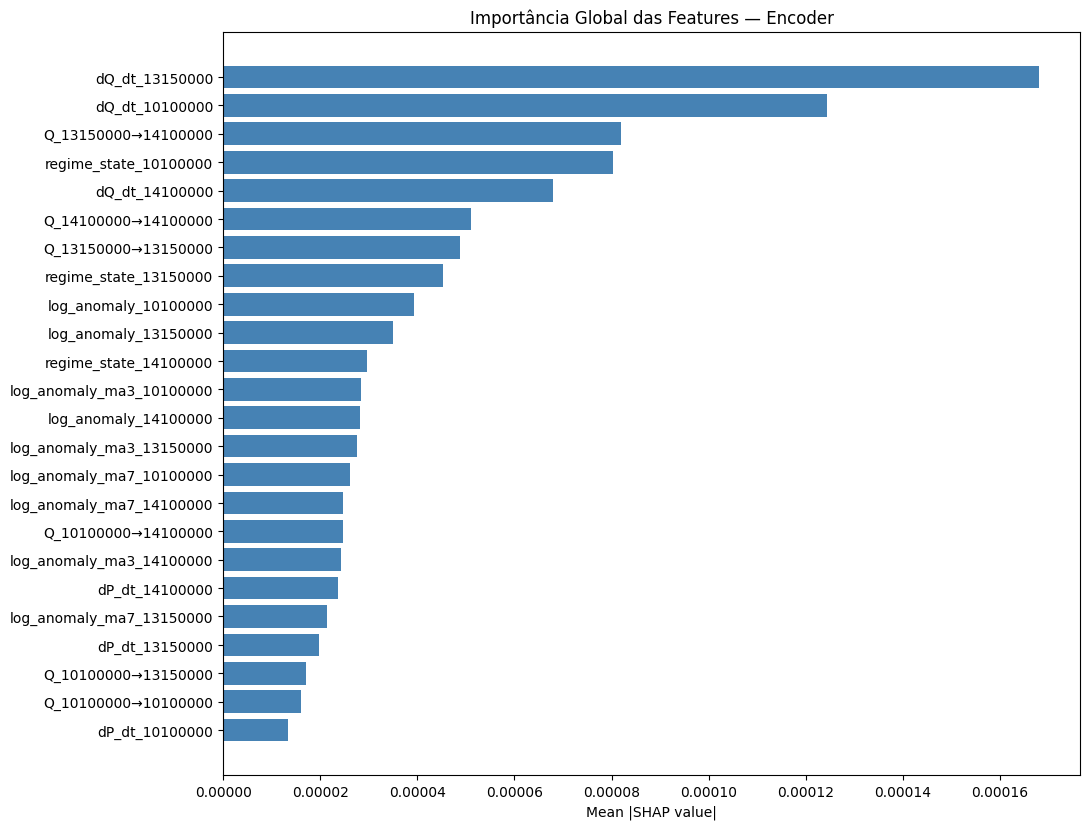


Ranking de importância:
   1. dQ_dt_13150000                                0.00017  ██████████████████████████████
   2. dQ_dt_10100000                                0.00012  ██████████████████████
   3. Q_13150000→14100000                           0.00008  ██████████████
   4. regime_state_10100000                         0.00008  ██████████████
   5. dQ_dt_14100000                                0.00007  ████████████
   6. Q_14100000→14100000                           0.00005  █████████
   7. Q_13150000→13150000                           0.00005  ████████
   8. regime_state_13150000                         0.00005  ████████
   9. log_anomaly_10100000                          0.00004  ███████
  10. log_anomaly_13150000                          0.00003  ██████
  11. regime_state_14100000                         0.00003  █████
  12. log_anomaly_ma3_10100000                      0.00003  █████
  13. log_anomaly_14100000                          0.00003  █████
  14. log_anomaly_ma3_13

In [62]:
# ── CÉLULA SHAP 6: Visualização — Importância Global ────────────────────────

# Remove dimensão extra do unsqueeze(-1) se existir
shap_array_clean = np.array(shap_values)
if shap_array_clean.ndim == 4:
    shap_array_clean = shap_array_clean.squeeze(-1)  # (n_test, enc_len, n_features)

print(f"shap_array shape final: {shap_array_clean.shape}")

# Agrega |SHAP| sobre batch e timesteps → importância média por feature
shap_global = np.abs(shap_array_clean).mean(axis=(0, 1))   # (n_features,)
sorted_idx  = np.argsort(shap_global)[::-1].tolist()        # ✅ .tolist() evita o TypeError

# ── Gráfico de barras horizontal ──
plt.figure(figsize=(11, max(6, len(encoder_feature_names) * 0.35)))
plt.barh(
    [encoder_feature_names[i] for i in sorted_idx[::-1]],
    [shap_global[i] for i in sorted_idx[::-1]],
    color='steelblue',
)
plt.xlabel('Mean |SHAP value|')
plt.title('Importância Global das Features — Encoder')
plt.tight_layout()
plt.show()

# ── Ranking no console ──
print('\nRanking de importância:')
max_val = shap_global[sorted_idx[0]]
for rank, i in enumerate(sorted_idx, 1):
    bar = '█' * int(shap_global[i] / max_val * 30)
    print(f'  {rank:2d}. {encoder_feature_names[i]:<45s} {shap_global[i]:.5f}  {bar}')

C:\Users\emily\AppData\Local\Temp\ipykernel_385076\2206717903.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


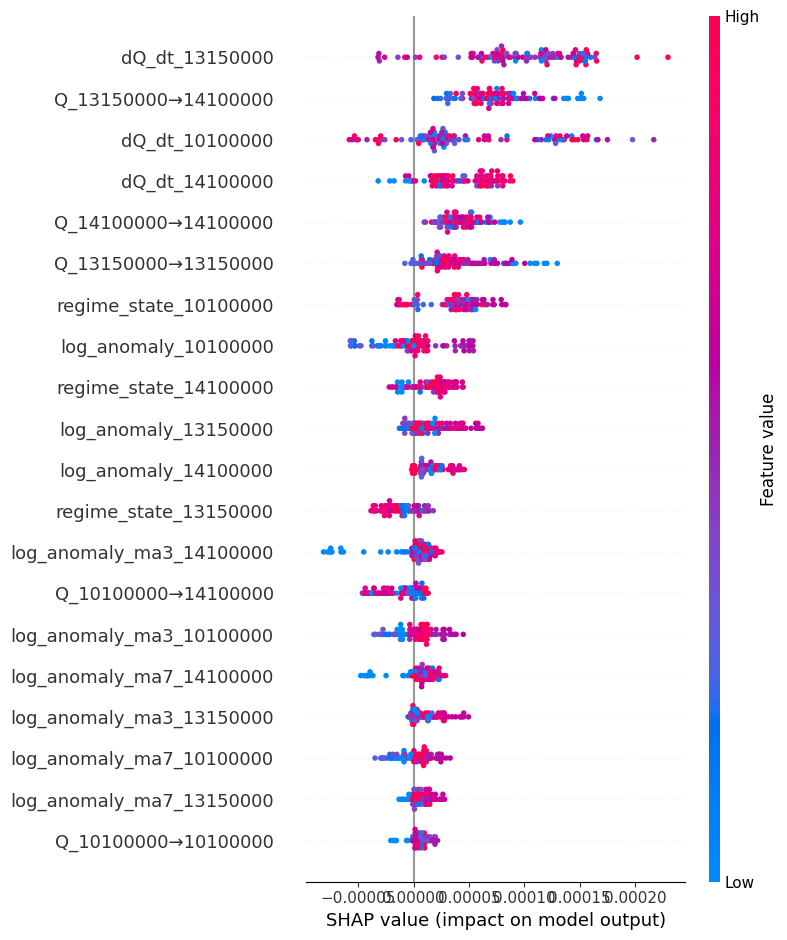

In [63]:
# ── CÉLULA SHAP 7: Summary plot ──────────────────────────────────────────────

shap_flat = shap_array_clean.mean(axis=1)        # (n_test, n_features)
X_flat    = test_enc.detach().numpy().mean(axis=1)  # (n_test, n_features)

shap.summary_plot(
    shap_flat,
    X_flat,
    feature_names=encoder_feature_names,
    max_display=min(20, len(encoder_feature_names)),
    show=True,
)